In [11]:
# import os; os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.2' # NOTE: jax preallocates GPU (default 75%)


import jax.numpy as jnp
import numpy as np
from numba import vectorize, njit, prange, jit
import jax.scipy.special as jsp
import numba
import math
from jax import jit
import gc

from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import jax
from scipy.interpolate import CubicSpline as CS
from functools import partial
import jax.random as jrandom
import HOD_NRV
from HOD_NRV.utils import random_uniform_jax,random_uniform_numba,random_poisson_jax,random_poisson_numba
import pyccl as ccl

In [123]:
from astropy.cosmology import FlatLambdaCDM
cosmo1 = FlatLambdaCDM(Om0=0.31,H0=100)
cosmo2 = FlatLambdaCDM(Om0=0.31,H0=70)

In [127]:
import cosmoprimo
cosmoprimo.cosmology

<module 'cosmoprimo.cosmology' from '/Users/ler13nrv/miniconda3/envs/NRV_ENV/lib/python3.11/site-packages/cosmoprimo/cosmology.py'>

In [126]:
print(cosmo1.comoving_distance(0.7),0.7*cosmo2.comoving_distance(0.7))

1746.035346559322 Mpc 1746.0353465593219 Mpc


In [12]:
from HOD_NRV.utils import set_mass_function

cosmo_params = {
    'h': 0.6774,
    'Om0': 0.3089,
    'Ob0': 0.0486,
    'sigma8': 0.8159,
    'ns': 0.9667,
    'm_nu': 0
}

# Create a CCL cosmology object
cosmology = ccl.Cosmology(
    h=cosmo_params['h'],  # CCL uses h rather than H0
    Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],  # Omega_cdm = Omega_m - Omega_b
    Omega_b=cosmo_params['Ob0'],
    sigma8=cosmo_params['sigma8'],
    n_s=cosmo_params['ns'],
    m_nu=cosmo_params['m_nu']
)

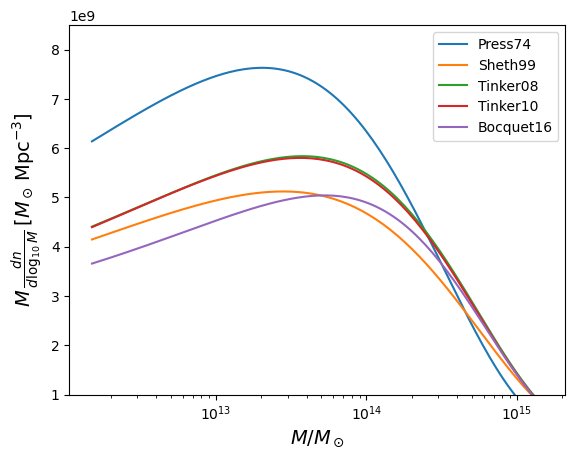

In [13]:
# Cosmology
cosmo = ccl.Cosmology(Omega_b=0.0492, Omega_c=0.2650, h=0.6724, A_s=2.2065e-09, n_s=0.9645)

# Array of masses
m_arr = np.geomspace(1.01E12,1E15,128)/cosmo['h']

# Array of redshifts
z_arr = np.linspace(0.,1.,16)

# Delta=200 (matter).
hmd_200m = ccl.halos.MassDef200m

# Delta=200 (critical).
hmd_200c = ccl.halos.MassDef200c

# Delta=500 (matter).
hmd_500m = ccl.halos.MassDef(500, 'matter')

# Virial overdensity
hmd_vir = ccl.halos.MassDefVir

# FoF mass definition
hmd_fof = ccl.halos.MassDefFof

hmfs = []
# Press & Schechter mass function
hmfs.append(ccl.halos.MassFuncPress74(mass_def=hmd_fof))

# Sheth & Tormen mass function
hmfs.append(ccl.halos.MassFuncSheth99(mass_def=hmd_fof))

# Tinker 2008 mass function
hmfs.append(ccl.halos.MassFuncTinker08(mass_def=hmd_200m))

# Tinker 2010 mass function
hmfs.append(ccl.halos.MassFuncTinker10(mass_def=hmd_200m))

# Bocquet 2016 mass function
hmfs.append(ccl.halos.MassFuncBocquet16(mass_def=hmd_200m))



# Let's plot all of them at z=0
plt.figure()
for mf in hmfs:
    nm = mf(cosmology, m_arr, 1.)
    plt.plot(m_arr,
             m_arr * nm, label=mf.name)
plt.xscale('log')
plt.ylim([1E9,8.5E9])
plt.legend()
plt.xlabel(r'$M/M_\odot$', fontsize=14)
plt.ylabel(r'$M\,\frac{dn}{d\log_{10}M}\,[M_\odot\,{\rm Mpc}^{-3}]$',
           fontsize=14);

In [120]:
ccl.background.rho_x(cosmology,1./(1+0.7),'matter')/1e10*cosmo_params['h']**3

6.007737384527276

In [ ]:
logM = np.geomspace(10,15,1000)
logM2 = np.geomspace(10,15,1000)
hmd = ccl.halos.MassDefVir
mass_function = ccl.halos.MassFuncTinker08(mass_def=hmd)
dndlogM2 = mass_function(cosmo,10**logM2/cosmo_params['h'],1./(1+0.7))

In [24]:
cosmo_params2 = {'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8': 0.8159, 'ns': 0.9667}


In [25]:
import numpy as np
logM_bins = np.logspace(11,15,1024)
np.log10(logM_bins)

array([11.        , 11.00391007, 11.00782014, ..., 14.99217986,
       14.99608993, 15.        ])

In [26]:
dndlogM=set_mass_function(cosmo_params2,np.log10(logM_bins),0.7)

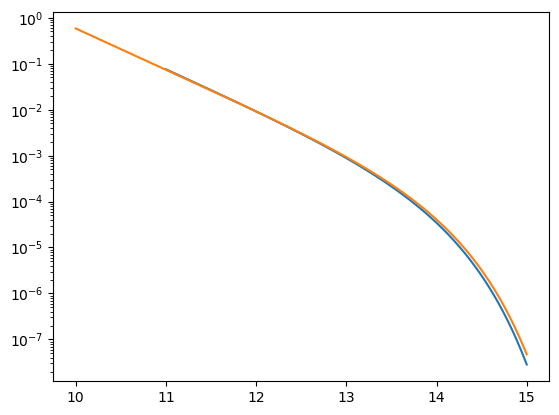

In [27]:
plt.semilogy(np.log10(logM_bins),dndlogM)
plt.semilogy(logM,dndlogM2/cosmo_params['h']**3)

In [2]:
import pandas as pd
import jax.numpy as jnp
import gc
import pandas as pd
import jax.numpy as jnp
from jax.tree_util import register_pytree_node_class

# Step 1: Read the parquet file with pandas

# Convert each column of the DataFrame to a JAX array.
# Here we are assuming that each DataFrame column is numeric.

class JaxDataSet:
    def __init__(self, df: pd.DataFrame, columns=None):
        object.__setattr__(self, '_columns', [])

        # Use specified columns or all if None
        if columns is None:
            columns = df.columns
        else:
            columns = list(columns)

        for col in columns:
            setattr(self, col, jnp.array(df[col].values))

    def __setattr__(self, name, value):
        if not name.startswith('_') and isinstance(value, jnp.ndarray):
            if name not in self._columns:
                self._columns.append(name)
        object.__setattr__(self, name, value)

    def __getitem__(self, mask):
        out = JaxDataSet.__new__(JaxDataSet)
        object.__setattr__(out, '_columns', self._columns.copy())
        for col in self._columns:
            setattr(out, col, getattr(self, col)[mask])
        return out

    @property
    def columns(self):
        return self._columns
    
df = pd.read_parquet('/Users/ler13nrv/Documents/halo_catalogue.parquet')
    
JaxData = JaxDataSet(df)

In [8]:
JaxData_reduced = JaxDataSet(df,columns=['x','y','z','vx','vy','vz'])

In [9]:
JaxData.mvir

Array([6.7055e+11, 1.3404e+11, 1.0572e+11, ..., 8.0031e+10, 7.5420e+10,
       7.8385e+10], dtype=float32)

In [10]:
JaxData_reduced = JaxData_reduced[JaxData_reduced.x > 500]

In [5]:
JaxData.logM = jnp.log10(JaxData.mvir)

In [7]:
JaxData.logM

Array([11.82643 , 11.127234, 11.024157, ..., 10.903258, 10.877486,
       10.894233], dtype=float32)

In [4]:
halo_catalogue = JaxDataset('/Users/ler13nrv/Documents/halo_catalogue.parquet')

In [5]:
halo_catalogue.logM = jnp.log10(halo_catalogue.mvir)

In [8]:
df2 = halo_catalogue[halo_catalogue.mvir > 2000]

In [3]:
b = np.column_stack([halo.b_x,halo.b_y,halo.b_z])
a = np.column_stack([halo.a_x,halo.a_y,halo.a_z])
b = b/np.linalg.norm(b,axis=1)[:,None]
a = a/np.linalg.norm(a,axis=1)[:,None]
c = np.cross(b,a)

In [ ]:
HOD_model =HOD_NRV.HOD_models.Occupation("ELG_GHOD")
Ac = 1.
Mmin = 12.
sig_M = 0.6
M1 = 13.
As = 1.
alpha = 0.6
kappa = 0.8
logM = jnp.geomspace(10.6,15,1000)
dict_params = {'kappa':kappa,'Ac':Ac,'As':As,'Mmin':Mmin, 'sig_M':sig_M,'M1':M1,'alpha':alpha}
HOD_model.set_params(dict_params)



In [5]:
HOD_model.compute_fsat(dict_params)

AttributeError: 'Occupation' object has no attribute 'logM_bins'

In [15]:
@partial(jit,static_argnames=['size'])
def random_uniform_jax(key,size,a=0,b=1):
    result = jrandom.uniform(key,size,minval=a,maxval=b)
    return result

def random_poisson_jax(key,prob):
    result = jrandom.poisson(key,prob, (prob.shape[0],))
    return result


def sample_unit_sphere_jax(key_theta,key_phi, N):
    """
    Parameters
    ----------
    key_theta : key
    key_phi : key
    N : number of simulated points 
    
    Returns 
    ----------
    Generates a random distribution on the unit sphere.
    """
    
    theta = jnp.arccos(1 - 2 * random_uniform_jax(key_theta,N))
    phi = 2 * jnp.pi * 2 * random_uniform_jax(key_phi,N)
    x = jnp.sin(theta) * jnp.cos(phi)
    y = jnp.sin(theta) * jnp.sin(phi)
    z = jnp.cos(theta)
    return jnp.stack((x, y, z), axis=1)

def create_point_on_unit_sphere(key):
    key_theta, key_phi = jrandom.split(key,num=2)
    SpherePoints = sample_unit_sphere_jax(key_theta,key_phi,N=1_000_000)
    return SpherePoints


@jit
def NFW_CDF(r,Rs,c):
    """
    Parameters
    ----------
    r : radius 
    r_s : scale radius of the NFW profile
    c : Concentration of the NFW profile
    
    Returns 
    ----------
    Return the CDF of the NFW profile.

    """
    CDF = (jnp.log(1+r/Rs) - (r/Rs)/(1+r/Rs))/(jnp.log(1+c) - c/(1+c))
    return CDF

@jit
def single_inverse_CDF(u,Rvir,Rs,c):
    """
    Parameters
    ----------
    r : radius 
    r_s : scale radius of the NFW profile
    c : Concentration of the NFW profile
    
    Returns 
    ----------
    Return the inverse CDF of the NFW profile.

    """
    rbins = jnp.geomspace(0.1, Rvir, 500)
    cdf = NFW_CDF(rbins,Rs,c)
    return jnp.interp(u,cdf,rbins)

@jit
def NFW_radius(u_samples,Rvir,c,mask):

    """
    Parameters
    ----------
    u_samples : Array of shape (Ns_max, N_halo) with Ns_max = max(N_s) with N_s the number of satellites per halo,
    and N_halo the total number of halo. random uniform distribution of points in [0,1]  
    Rvir : Virial radius of th halos
    c : Concentration of the halos
    mask : boolean array of shape u_samples 
    
    Returns 
    ---------- 
    Return the randomly draw NFW radii.

    """
    Rs=Rvir/c
    # vmap across satellites within each halo, then halos
    batched_eval = vmap(
        vmap(single_inverse_CDF,in_axes=(0, None, None, None)),  # over satellites
        in_axes=(0, 0, 0, 0)  # over halos
    )
    
    r_samples = batched_eval(u_samples,Rvir,Rs,c)

    # Optionally mask padded outputs
    r_samples = jnp.where(mask, r_samples, jnp.nan)
    return jnp.hstack(r_samples)



@partial(jit,static_argnames=['N_s_tot'])
def spherical_NFW_satellites_positions(key,SpherePoints, halo_centers, Rvir, c, N_s, N_s_tot):
    """
    Generate NFW satellite positions with improved performance
    
    Parameters
    ----------
    key : PRNG key
    halo_centers : Array of shape (num_halos, 3) with halo center coordinates
    Rvir : Array of shape (num_halos,) with virial radii
    c : Array of shape (num_halos,) with concentration parameters
    N_s : Array of shape (num_halos,) with number of satellites per halo
    
    Returns
    -------
    sat_positions : Array with satellite positions
    """
    num_halos = len(Rvir)
    Rs = Rvir / c
    
    key, key_r, key_theta = jrandom.split(key, 3)
    u_samples = random_uniform_jax(key_r, (N_s_tot,))
    
    # Create arrays that map each satellite to its halo properties
    halo_indices = jnp.repeat(jnp.arange(num_halos), N_s,total_repeat_length=N_s_tot)
    sat_Rs = Rs[halo_indices]
    sat_c = c[halo_indices]
    sat_Rvir = Rvir[halo_indices]
    
    radii = vmap(single_inverse_CDF)(u_samples, sat_Rvir, sat_Rs, sat_c)
    coordinates = jrandom.permutation(key_theta,SpherePoints)[:N_s_tot]    
    sat_positions = coordinates * (radii / 1000)[:, None] + halo_centers[halo_indices]
    
    return sat_positions


@partial(jit,static_argnames=['N_tot'])
def dispersion_velocities_satellites(key, halo_velocities, vrms_h, satellite_counts,N_tot):
    num_halos = len(halo_velocities)

    indices = jnp.repeat(jnp.arange(num_halos), satellite_counts,total_repeat_length=N_tot)
    sig = vrms_h[indices] * 0.577
    key_vx, key_vy, key_vz = jrandom.split(key, 3)
    vx_sat = jrandom.normal(key_vx, shape=(len(indices),)) * sig + halo_velocities[indices, 0]
    vy_sat = jrandom.normal(key_vy, shape=(len(indices),)) * sig + halo_velocities[indices, 1]
    vz_sat = jrandom.normal(key_vz, shape=(len(indices),)) * sig + halo_velocities[indices, 2]
    return jnp.column_stack([vx_sat, vy_sat, vz_sat])



# def spherical_NFW_satellites_positions(key, SpherePoints, halo_centers, halo_Rvir, halo_concentration, halo_N_s, N_halo):


#     max_N_s, tot_N_s = jnp.max(halo_N_s),jnp.sum(halo_N_s)

#     key, key_r, key_theta = jrandom.split(key,num=3)
#     u_samples = random_uniform_jax(key_r,(N_halo, max_N_s))

#     # Create the mask: True where index < N_s[i]
#     indices = jnp.arange(max_N_s)
#     mask = indices[None, :] < halo_N_s[:, None]

#     # Zero out invalid entries (optional, only if needed; could also just use the mask)
#     # u_samples_padded = jnp.where(mask, u_samples, 0.0)
#     radius = NFW_radius(u_samples,halo_Rvir,halo_concentration,mask)
#     mask = ~jnp.isnan(radius)
#     radius = radius[mask]

#     coordinates = jrandom.permutation(key_theta,SpherePoints)[:tot_N_s]
#     halo_centers = jnp.repeat(halo_centers,halo_N_s,axis=0)

#     sat_positions = coordinates*radius[:,None]/1000 + halo_centers
#     return sat_positions

In [6]:
1 + None

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

In [428]:
def sample_with_random(key, shape):
    @jax.jit
    def _sample(k):
        k1, k2 = jrandom.split(k)
        #samples1 = jrandom.normal(k1, shape)
        samples2 = jrandom.uniform(k2, shape)
        return samples2
    
    return _sample(key)

# Usage
key = jrandom.PRNGKey(42)
x= sample_with_random(key, (int(1e8),))

In [60]:
halo

,id,mvir,x,y,z,vx,vy,vz,rvir,rs_klypin,...,a_x,a_y,a_z,b_x,b_y,b_z,b_to_a,c_to_a,scale_of_last_mm,spin_bullock
0,17419206953,6.705500e+11,120.079659,23.453461,9.042600,-68.029999,23.180000,536.119995,209.811005,21.890900,...,16.373899,8.77125,-5.90926,-3.10434,14.39740,12.76860,0.81407,0.54023,0.23176,0.01928
1,17419207455,1.340400e+11,114.328247,11.533690,14.533700,549.320007,718.330017,-485.279999,122.678001,14.764200,...,0.806390,-1.61425,12.43370,1.32128,12.40090,1.52430,0.75692,0.69425,0.13207,0.02942
2,17419210689,1.057200e+11,114.978683,24.951130,13.029840,634.750000,33.259998,411.850006,113.345001,12.386500,...,11.025800,-1.12982,-4.83690,3.48911,-6.61978,9.49978,0.81208,0.68024,0.31597,0.04859
3,17419210772,1.027600e+11,113.348679,24.212721,11.776540,915.200012,70.080002,52.529999,112.276001,11.056500,...,8.730840,-2.23772,0.50046,0.90569,5.17533,7.34037,0.95355,0.70135,0.20287,0.02269
4,17419211290,7.509100e+10,113.191063,14.011900,10.025470,595.469971,987.270020,-0.680000,101.129997,4.879260,...,2.815940,3.89686,2.33894,4.24924,-3.23357,0.27156,0.74463,0.65029,0.18989,0.02843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48944143,18031447387,1.175800e+11,703.184326,136.350967,381.087158,188.520004,130.570007,0.940000,117.432999,17.957600,...,5.015440,-7.58535,13.73320,15.65240,3.40188,-3.83733,0.47112,0.41610,0.13734,0.04437
48944144,18031450471,8.464200e+10,672.554871,98.181839,342.291656,255.380005,115.730003,430.269989,105.248001,13.052900,...,7.075460,3.96557,1.46949,-3.91186,7.22531,-0.66303,0.74863,0.60560,0.13734,0.01185
48944145,18031454742,8.003100e+10,730.577393,89.691116,342.119019,55.320000,-133.130005,516.219971,103.301003,9.746340,...,9.410360,6.47809,-2.80347,-4.84892,9.32790,5.27808,0.85465,0.68315,0.13207,0.03827
48944146,18031455078,7.542000e+10,645.081726,125.268250,363.823517,167.679993,272.579987,24.610001,101.278000,26.014999,...,17.239000,-2.93060,1.63796,1.86902,15.49540,8.05317,0.43069,0.36530,0.39440,0.03391


In [432]:
%%time
x= sample_with_random(key, (int(1e8),))

CPU times: user 134 ms, sys: 54.1 ms, total: 189 ms
Wall time: 96.2 ms


In [435]:
@partial(jit,static_argnames=['size'])
def random_uniform_jax(key,size,a=0,b=1):
    result = jrandom.uniform(key,size,minval=a,maxval=b)
    return result

In [437]:
%%time
dd = random_uniform_jax(key,(int(1e8),))

CPU times: user 13 ms, sys: 59.6 ms, total: 72.6 ms
Wall time: 18.6 ms


In [440]:
%%time
ss = jrandom.uniform(key,int(1e8),minval=0,maxval=1)

CPU times: user 6.46 ms, sys: 28.2 ms, total: 34.6 ms
Wall time: 9.32 ms


In [368]:
ss

Array([0.8423141 , 0.18237865, 0.2271781 , ..., 0.86112213, 0.9693271 ,
       0.33694518], dtype=float32)

In [20]:
#%%time
#sat_positions = optimized_NFW_satellites(key,SpherePoints,centers,Rvir,c,N_s)
number1,number2 = 20000, 30000
Rvir = jnp.array(halo.rvir[0:number1].values)
Rs = jnp.array(halo.rs_klypin[0:number1].values)
N_s = jnp.array(np.random.randint(1,50,number1))
c = Rvir/Rs
centers = jnp.stack([halo.x.values,halo.y.values,halo.z.values],axis=1)[0:number1]
velocities = jnp.stack([halo.vx.values,halo.vy.values,halo.vz.values],axis=1)[0:number1]
vrms = halo.vrms.values[0:number1]
N_s_tot = int(np.sum(N_s))
num_halos = jnp.size(Rvir)
max_N_s = jnp.int32(N_s.max())
u_samples_padded = jnp.zeros((num_halos, max_N_s))
mask = jnp.zeros((num_halos, max_N_s), dtype=bool)


Rvir2 = jnp.array(halo.rvir[0:number2].values)
Rs2 = jnp.array(halo.rs_klypin[0:number2].values)
N_s2 = jnp.array(np.random.randint(1,50,number2))
c2 = Rvir2/Rs2
centers2 = jnp.stack([halo.x.values,halo.y.values,halo.z.values],axis=1)[0:number2]
velocities2 = jnp.stack([halo.vx.values,halo.vy.values,halo.vz.values],axis=1)[0:number2]
vrms2 = halo.vrms.values[0:number2]
N_s_tot2 = jnp.sum(N_s2)
num_halos2 = jnp.size(Rvir2)
max_N_s = jnp.int32(N_s.max())
u_samples_padded = jnp.zeros((num_halos, max_N_s))
mask = jnp.zeros((num_halos, max_N_s), dtype=bool)

In [58]:
%%time
np.random.uniform(0,int(1e32))

CPU times: user 26 μs, sys: 3 μs, total: 29 μs
Wall time: 35 μs


7.712675471148864e+31

In [7]:
key = jrandom.PRNGKey(0)
key2 = jrandom.PRNGKey(1)

key, key_r, key_angles = jrandom.split(key,num=3)
SpherePoints = create_point_on_unit_sphere(key)


In [33]:
random_poisson_numba(N_s)

NumbaValueError: unsupported PEP 3118 format '=i'

In [32]:
%%time
random_poisson_jax(key2,N_s)

CPU times: user 775 μs, sys: 464 μs, total: 1.24 ms
Wall time: 666 μs


Array([ 8, 14, 30, ..., 24, 37, 31], dtype=int32)

In [24]:

%%time
sat_positions = spherical_NFW_satellites_positions(key,SpherePoints,centers,Rvir,c,N_s,N_s_tot)


CPU times: user 805 μs, sys: 2.51 ms, total: 3.32 ms
Wall time: 621 μs


In [22]:
%%time
sat_vel = dispersion_velocities_satellites(key,velocities,vrms,N_s,N_s_tot)


CPU times: user 1.25 ms, sys: 1.59 ms, total: 2.85 ms
Wall time: 596 μs


In [1]:
sat_positions

NameError: name 'sat_positions' is not defined

In [262]:
SpherePoints

Array([[ 0.23175094,  0.87031555,  0.43456006],
       [-0.31051603, -0.75602895, -0.57619447],
       [-0.0745548 ,  0.9759534 ,  0.20483297],
       ...,
       [-0.7486327 , -0.46728033,  0.47031713],
       [-0.165476  , -0.12641364, -0.97807837],
       [-0.27956167, -0.77030516,  0.5731275 ]], dtype=float32)

In [159]:
%%time
sat_positions2 = spherical_NFW_satellites_positions(key2,SpherePoints,centers,Rvir,c,N_s,num_halos)

CPU times: user 421 ms, sys: 30.9 ms, total: 452 ms
Wall time: 330 ms


In [89]:
sat_positions2.shape

(500890, 3)

In [7]:
SpherePoints = create_point_on_unit_sphere(key)

In [24]:
N_s

Array([35, 64, 45, ...,  6, 86, 58], dtype=int32)

In [29]:
np.sum(N_s)

Array(1002600, dtype=int32)

CPU times: user 468 ms, sys: 55.2 ms, total: 524 ms
Wall time: 346 ms


In [44]:
sat_positions

Array([[120.085815,  23.401152,   9.01381 ],
       [119.99799 ,  23.478682,   9.032956],
       [120.107735,  23.436256,   9.048843],
       ...,
       [621.27936 , 804.9319  , 769.4111  ],
       [621.1873  , 804.9855  , 769.39844 ],
       [621.27545 , 805.0125  , 769.3678  ]], dtype=float32)

In [83]:
N_s

Array([3, 1, 1, ..., 1, 1, 3], dtype=int32)

In [129]:
radius[0:15]

Array([[120.169235 ,  23.528444 ,   9.068723 ],
       [120.069145 ,  23.430492 ,   9.067037 ],
       [120.21369  ,  23.501219 ,   9.090652 ],
       [114.34048  ,  11.538876 ,  14.523297 ],
       [114.329414 ,  11.529113 ,  14.533499 ],
       [115.02491  ,  24.933914 ,  13.070913 ],
       [113.32814  ,  24.21703  ,  11.79667  ],
       [113.40711  ,  24.24171  ,  11.828739 ],
       [113.32955  ,  24.220835 ,  11.779308 ],
       [113.18779  ,  14.016148 ,  10.017109 ],
       [113.214005 ,  13.9980345,  10.014169 ],
       [113.190575 ,  14.0133095,  10.027597 ],
       [996.7863   ,  19.145365 ,  13.397915 ],
       [996.7763   ,  19.115665 ,  13.302412 ],
       [ 34.94255  ,  14.69905  ,  57.948826 ]], dtype=float32)

In [84]:
N_s.max()

Array(3, dtype=int32)

In [131]:
radius[radius > 1000]

Array([], shape=(0,), dtype=float32)

In [45]:

import jax.scipy.interpolate as jinterp
# interpolate = RegularGridInterpolator(points, values, method='linear')

    

@partial(jit,static_argnames='num_point')
def inverse_CDF(c,rs,Rvir,key,num_point):
    r  = jnp.logspace(-2,jnp.log10(Rvir),num_point)
    key,subkey = jrandom.split(key)
    CDF = NFW_CDF(r,rs,c)
    uniform_random = jrandom.uniform(subkey, shape=(num_point,))
    inverse_cdf = jnp.interp(uniform_random, CDF, r)
    return inverse_cdf

@partial(jit,static_argnames='num_point')
def nfw_inv_cdf_sampler(u, Rs, Rvir, key, num_point):
    r_vals = jnp.linspace(1e-3, Rvir, 1000)
    x = r_vals / Rs
    m_vals = jnp.log(1 + x) - x / (1 + x)
    CDF = m_vals / m_vals[-1]
    r_samples = jnp.interp(u,CDF, r_vals)
    return r_samples

In [92]:
%%time
key = jrandom.key(0)
key, subkey_r, subkey_theta = jrandom.split(key,num=3)
u_samples_all = random_uniform_jax(subkey,(num_halos, max_N_s))

# Create the mask: True where index < N_s[i]
indices = jnp.arange(max_N_s)
mask = indices[None, :] < Ns[:, None]

# Zero out invalid entries (optional, only if needed; could also just use the mask)
u_samples_padded = jnp.where(mask, u_samples_all, 0.0)

NameError: name 'subkey' is not defined

In [23]:
Ns

Array([ 7,  1,  3, ..., 16, 24, 13], dtype=int32)

In [69]:
def inverse_CDF(u, Rvir_i, rs_i, c_i):
    r_grid = jnp.geomspace(0.001, Rvir_i, 1000)
    cdf = NFW_CDF(r_grid, rs_i, c_i)
    return jnp.interp(u, cdf, r_grid)

@jax.jit
def batch_inverse_cdf(u_samples, Rvir, c, mask):
    rs = Rvir / c

    # vmap across satellites within each halo, then halos
    batched_eval = jax.vmap(
        jax.vmap(single_eval, in_axes=(0, None, None, None)),  # over satellites
        in_axes=(0, 0, 0, 0)  # over halos
    )
    
    r_samples = batched_eval(u_samples, Rvir, rs, c)

    # Optionally mask padded outputs
    r_samples = jnp.where(mask, r_samples, jnp.nan)
    return r_samples

In [73]:
Ns

Array([21, 14, 13, ...,  8, 16,  5], dtype=int32)

In [75]:
%%time
ssxq= batch_inverse_cdf(u_samples_all, Rvir, c, mask)

CPU times: user 219 μs, sys: 268 μs, total: 487 μs
Wall time: 188 μs


In [77]:
ssxq[~jnp.isnan(ssxq)].shape

(250087,)

In [27]:
@partial(jit,static_argnames=["N"])
def single_halo(r_grid,Rvir, Rs, N):
    key = jrandom.key(np.random.randint(0,int(2**32)))
    x = r_grid / Rs
    m_vals = jnp.log(1 + x) - x / (1 + x)
    CDF = m_vals / m_vals[-1]
    u = random_uniform_jax(key,N)
    r_samples = jnp.interp(u,CDF, r_grid)
    return r_samples


#@partial(jit, static_argnames=["num_points"])
def batched_inverse_cdf(Rvir_array, Rs_array,N, num_points=1024):
    r_grid = jnp.logspace(-3, jnp.log10(Rvir_array), num_points)
    return vmap(single_halo)(r_grid,Rvir_array, Rs_array,N)

In [28]:
N = jnp.array(np.random.randint(1,100,size=len(Rvir)))
result=batched_inverse_cdf(Rvir,Rs,Ns)

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * most axes (3 of them) had size 20000, e.g. axis 0 of argument Rvir of type float32[20000];
  * one axis had size 1024: axis 0 of argument r_grid of type float32[1024,20000]

In [15]:
grid_size=80

In [16]:
@partial(jit, static_argnames=['grid_size', 'cdf_points'])
def create_nfw_emulator(grid_size=80, cdf_points=1000):
    """
    Create an emulator for NFW profiles based on a grid of parameters
    
    Args:
        grid_size: Number of grid points for each parameter
        cdf_points: Number of points to use for the CDF evaluation
        
    Returns:
        Interpolator function that can quickly evaluate inverse CDF
    """
    # Create parameter grids
    u_grid = jnp.linspace(0.001, 0.999, 300)  # Uniform random values
    c_grid = jnp.geomspace(1, 30, grid_size)        # Concentration values from 1 to ~31.6
    Rvir_grid = jnp.geomspace(0.05,4, grid_size)      # Virial radii from 0.1 to 100
    # Create meshgrid for all parameter combinations
    u_mesh, c_mesh, Rvir_mesh = jnp.meshgrid(u_grid, c_grid, Rvir_grid, indexing='ij')
    
    # Compute rs from concentration and Rvir
    rs_mesh = Rvir_mesh / c_mesh
    
    # Compute r values (result of inverse CDF) for each parameter combination
    # We need to compute the CDF at many radii and then interpolate
    def compute_single_inverse_cdf(c, rs, Rvir, u):
        r_values = jnp.geomspace(0.001, Rvir, cdf_points)
        cdf_values = NFW_CDF(r_values, rs, c)
        return jnp.interp(u, cdf_values, r_values)
    
    # Use vmap to vectorize over all parameter combinations
    compute_batch = jax.vmap(jax.vmap(jax.vmap(compute_single_inverse_cdf)))
    r_values = compute_batch(c_mesh, rs_mesh, Rvir_mesh, u_mesh)
    
    return r_values

In [17]:
c_grid = jnp.geomspace(1, 30, grid_size)        # Concentration values from 1 to ~31.6
Rvir_grid = jnp.geomspace(0.05,4, grid_size) 
r_grid = jnp.logspace(-3, jnp.log10(Rvir_grid.max()), 10000)
rs_grid = Rvir_grid/c_grid
u_grid = jnp.linspace(0.001, 0.999, 300)  # Uniform random values



In [18]:
u_data = jnp.repeat(u_grid, grid_size * grid_size)
c_data = jnp.tile(jnp.repeat(c_grid, grid_size), 300)
Rvir_data = jnp.tile(jnp.tile(Rvir_grid, grid_size), 300)



In [19]:
data_vector = np.column_stack([u_data,c_data,Rvir_data])

In [20]:
result=create_nfw_emulator(grid_size)

In [24]:
hparams = {'n_in':1, 'n_cond':3,'layers':[50,50,50],'activation':jax.nn.relu, 'n_components':2}
inference = NPE(model_class=MixtureDensityNetwork,model_hparams=hparams)

In [25]:
inference = inference.append_simulations(result.flatten()[:,None],data_vector)

[!] Inputs are valid.
[!] Appending 1920000 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 1344000 simulations.
[!] Validation set: 383999 simulations.
[!] Test set: 192001 simulations.


In [26]:
CHECKPOINT_PATH = "." 
import os
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

metrics,density_estimator = inference.train(training_batch_size=512,num_epochs=500,learning_rate=1e-4,checkpoint_path=CHECKPOINT_PATH)

Distribution subclass DistributionFromTFP inherits `_parameter_properties from its parent (MultivariateNormalTriL)
while also redefining `__init__`. The inherited annotations cover the following
parameters: dict_keys(['loc', 'scale_tril']). It is likely that these do not match the subclass parameters.
This may lead to errors when computing batch shapes, slicing into batch
dimensions, calling `.copy()`, flattening the distribution as a CompositeTensor
(e.g., when it is passed or returned from a `tf.function`), and possibly other
cases. The recommended pattern for distribution subclasses is to define a new
`_parameter_properties` method with the subclass parameters, and to store the
corresponding parameter values as `self._parameters` in `__init__`, after
calling the superclass constructor:

```
class MySubclass(tfd.SomeDistribution):

  def __init__(self, param_a, param_b):
    parameters = dict(locals())
    # ... do subclass initialization ...
    super(MySubclass, self).__init__(**ba

[!] Creating DataLoaders with batch_size 512.
[!] Building the neural network.
[!] Creating the Trainer module.

                         NDE_w_Standardization Summary                          
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ path          ┃ module        ┃ inputs        ┃ outputs       ┃ params       ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│               │ NDE_w_Standa… │ -             │ float32[1]    │              │
│               │               │ float32[1,1]  │               │              │
│               │               │ -             │               │              │
│               │               │ float32[1,3]  │               │              │
├───────────────┼───────────────┼───────────────┼───────────────┼──────────────┤
│ embedding_net │ Sequential    │ float32[1,3]  │ float32[1,3]  │              │
├───────────────┼───────────────┼───────────────┼───────────────┼────────────

Epochs: Val loss nan/ Best val loss -5.126:  33%|███▎      | 166/500 [03:58<07:59,  1.44s/it]   


Neural network training stopped after 167 epochs.
Early stopping with best validation metric: -5.125920295715332
Best model saved at epoch 146
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -4.947694301605225
[!] Validation loss: -5.125920295715332
[!] Test loss: -5.130916118621826


In [22]:
result.shape

(300, 80, 80)

In [50]:
elements = result[:, 40, 40]
profile = r_grid/rs_grid[40]/((1+r_grid/rs_grid[40])**2)

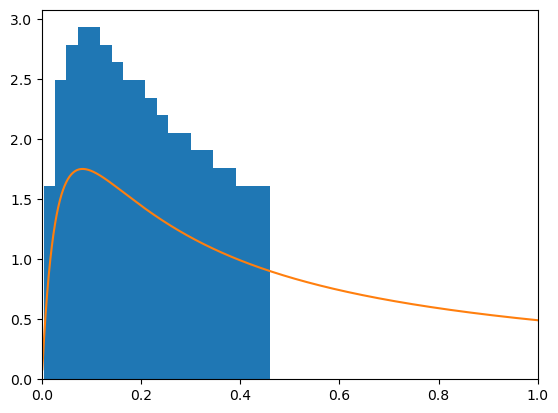

In [52]:
plt.xlim(0,1)
plt.hist(elements,bins=20,density=True)
plt.plot(r_grid,7*profile)

In [ ]:
    # Create parameter grids
    u_grid = jnp.linspace(0.001, 0.999, 200)  # Uniform random values
    c_grid = jnp.geomspace(1, 30, 60)        # Concentration values from 1 to ~31.6
    Rvir_grid = jnp.geomspace(0.05,4, 60)      # Virial radii from 0.1 to 100
    # Create meshgrid for all parameter combinations
    u_mesh, c_mesh, Rvir_mesh = jnp.meshgrid(u_grid, c_grid, Rvir_grid, indexing='ij')

In [ ]:
def generate_inverse_cdf_data(num_points=1024, num_u=512):
    r_grid = jnp.logspace(-2, jnp.log10(2.0), num_points)
    u_grid = jnp.linspace(0.001, 0.999, num_u)
    samples = []

    Rvir_vals = jnp.linspace(0.1, 2.0, 20)
    c_vals = jnp.linspace(3.0, 20.0, 20)

    for Rvir in Rvir_vals:
        for c in c_vals:
            Rs = Rvir / c
            CDF = NFW_CDF(r_grid, Rs, c)
            r_samples = jnp.interp(u_grid, CDF, r_grid)
            for i in range(num_u):
                samples.append([u_grid[i], Rvir, c, r_samples[i]])
    return jnp.array(samples)

In [ ]:
    r_grid = jnp.logspace(-2, jnp.log10(2.0), num_points)
    u_grid = jnp.linspace(0.001, 0.999, num_u)
    samples = []

    Rvir_vals = jnp.linspace(0.1, 2.0, 20)
    c_vals = jnp.linspace(3.0, 20.0, 20)

In [ ]:
r_grid = jnp.logspace(-3, jnp.log10(4.0), 512)
u_grid = jnp.linspace(1e-4, 1, 1024)
samples = []

Rvir_vals = jnp.linspace(1e-2, 2.0, 128)
c_vals = jnp.linspace(1.0, 20.0, 128)

In [ ]:
%%time
result=batched_inverse_cdf(Rvir,Rs,key)

CPU times: user 3.19 s, sys: 316 ms, total: 3.5 s
Wall time: 790 ms


In [ ]:
r = np.geomspace(1e-2,Rvir[0],10000)

def NFW_PDF(x):
    """ 
    Universal NFW PDF profile as a function of x = r/rs
    """
    return  x/((1 + x)**2)

profile = r/Rs[0]/((1+r/Rs[0])**2)

In [ ]:
profile

Array([0.00045639, 0.00045685, 0.0004573 , ..., 0.08569068, 0.08562157,
       0.08555249], dtype=float32)

In [ ]:
%%time
result = jax.vmap(inverse_CDF,in_axes=(0,0,0,None,None))(c,Rs,Rvir,key,10000)

CPU times: user 9.97 s, sys: 4.2 s, total: 14.2 s
Wall time: 3.66 s


In [ ]:
%%time

r  = jnp.logspace(-2,jnp.log10(Rvir[0]),1000)
CDF = NFW_CDF(r,Rs[0],Rvir[0])
uniform_random = jrandom.uniform(key, shape=(10000,))
inverse_cdf = jnp.interp(uniform_random, CDF, r)



CPU times: user 4.03 ms, sys: 5.04 ms, total: 9.07 ms
Wall time: 3.18 ms
